# TP1 — Sistema de Reconocimiento Facial

## Equipo
- Alumno 1 : Peralta Alejandro Sebastian

## 1. Pipeline

El sistema sigue el flujo:

```
Imagen → Detección → Alineación → Embedding → Comparación → Identificación
```

| Etapa | Función implementada | Qué hace |
|-------|---------------------|----------|
| Detección | `detect_faces` | Encuentra dónde hay caras y devuelve sus bounding boxes |
| Alineación | `align_face` | Recorta y endereza la cara usando 5 puntos faciales |
| Embedding | `extract_embedding_from_face` | Genera un vector de 512 números que representa la cara |
| Comparación | `similarity` | Calcula similitud entre dos embeddings |
| Identificación | `identify` | Busca el embedding más parecido en la base y devuelve el nombre |

## 2. Modelo elegido

**InsightFace `buffalo_l`** — es un pack que contiene dos modelos pre-entrenados:

- **RetinaFace**: detecta caras y devuelve los 5 puntos faciales (dos ojos, nariz, dos comisuras de la boca).
- **ArcFace**: convierte la cara alineada en un vector de 512 dimensiones.

### Por qué este modelo

- Está pre-entrenado y funciona muy bien sin necesidad de entrenar nada.
- Detección + embedding se ejecutan en una sola llamada (`FaceAnalysis.get(image)`), lo que simplifica el código.
- InsightFace es una librería estándar para reconocimiento facial.

### Por qué un sistema basado en embeddings y no un clasificador

El sistema podría haberse planteado de dos formas:

1. **Clasificador con N salidas** (una por persona conocida). Para reconocer a alguien nuevo habría que sumar una clase y reentrenar el modelo con todo el dataset. Cada vez que aparece una persona nueva, se reentrena.
2. **Modelo que genera embeddings** (lo que usamos). El modelo proyecta cada cara a un vector de 512 números. Caras de la misma persona quedan cerca en ese espacio; caras de personas distintas, lejos. Para "agregar" una persona, basta con guardar su vector en una base. Para reconocer, se compara el vector de una foto nueva contra los guardados y se elige el más parecido.

Elegimos la segunda opción porque:

- Agregar o sacar identidades no requiere reentrenar nada.
- Funciona con muy pocas fotos por persona (5–10 alcanzan).
- El caso "desconocido" se resuelve naturalmente con un umbral de similitud.
- Es el enfoque estándar en sistemas reales de reconocimiento facial.

### Trade-offs

- **A favor:** buena precisión, listo para usar, corre bien en CPU, escalable a muchas identidades sin reentrenar.
- **En contra:** descarga inicial de ~300MB la primera vez. Tiempo de inferencia ~100–200ms por imagen en CPU.

## 3. Fine-tuning

**No se realizó fine-tuning.** Justificación:

- El modelo viene pre-entrenado con un dataset grande de caras públicas, suficiente para que los embeddings separen bien identidades muy distintas.
- Reentrenar con pocas imágenes propias (5–10 por persona) tiende a empeorar el modelo: pierde la capacidad general que ya tenía y se vuelve frágil ante caras nuevas.
- El sistema fue planteado como **modelo pre-entrenado + base vectorial**: las identidades se agregan como nuevas filas en la base, no modificando los pesos del modelo. Esto permite sumar personas sin reentrenar.
- Si en algún momento el sistema tuviera que escalar a cientos o miles de identidades específicas de un dominio (por ejemplo, empleados de una empresa), entonces sí valdría la pena considerar fine-tuning. No es nuestro caso.

En resumen: usar el modelo tal cual y delegar la "personalización" a la base de embeddings es la opción más simple, robusta y alineada con el uso real del sistema.

## 4. Hiperparámetros

Todos configurables en el archivo `.env`:

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `MODEL_NAME` | `buffalo_l` | Pack de InsightFace que se carga |
| `FACE_SIZE` | `112` | Tamaño en píxeles de la cara alineada (lo que el modelo espera) |
| `EMBEDDING_DIM` | `512` | Dimensión del vector embedding |
| `SIMILARITY_METRIC` | `cosine` | Métrica de comparación entre embeddings |
| `SIMILARITY_THRESHOLD` | `0.55` | Umbral para decidir si una cara coincide con alguna registrada |
| `USE_PGVECTOR` | `true` | Usar PostgreSQL+pgvector en lugar de un JSON local |

## 5. Preprocesamiento

### Normalización

El preprocesamiento lo hace InsightFace internamente:

1. La imagen se redimensiona para la detección.
2. Una vez detectada la cara, se recorta y se endereza a `112×112` píxeles usando los 5 puntos faciales.
3. Los píxeles se normalizan antes de generar el embedding.
4. El embedding final queda con norma 1 (lo que permite usar similitud coseno directamente como producto interno).

No agregamos pasos de normalización adicionales para no duplicar lo que el modelo ya hace.

### Data augmentation

**No se aplicó data augmentation.** Razones:

- Augmentation (flip, rotaciones, ruido, cambios de brillo) tiene sentido cuando se entrena un modelo, para que aprenda a ser robusto ante esas variaciones.
- En nuestro caso no estamos entrenando. Usamos el modelo solo como extractor de embeddings.
- Generar variantes artificiales de una foto y promediar sus embeddings podría aumentar la robustez al registrar, pero también introduce ruido. Para el alcance de este TP no aporta lo suficiente.

### Filtrado de imágenes de baja calidad

El detector devuelve un valor de confianza (`det_score`) por cada cara encontrada. Caras con score bajo suelen corresponder a detecciones dudosas (cara muy lejana, ocluida, mal iluminada).

En la implementación actual no aplicamos un filtro explícito por score, pero la opción queda disponible como mejora futura: rechazar caras con `det_score < 0.6` antes de registrarlas evita que entren embeddings de mala calidad a la base.

Para mantener la calidad del dataset, en la práctica filtramos manualmente las fotos al armar el conjunto de registro: cara frontal, ojos visibles, sin oclusiones fuertes.

## 6. Modificaciones al backend

Además de implementar las 3 funciones requeridas (`detect_faces`, `align_face`, `extract_embedding_from_face`), se hicieron tres cambios mínimos justificados:

### 6.1 `_load_model` en `src/lib/services/face_service.py`

**Cambio:** se agregó un caso adicional al loader para soportar packs de InsightFace.

**Justificación:** el pack `buffalo_l` no es un único archivo `.pth` o `.onnx`, sino una carpeta con varios modelos. El loader original solo aceptaba archivos sueltos. El comportamiento previo se mantiene intacto.

### 6.2 `/health` en `src/app/main.py`

**Cambio:** la verificación de archivo se aplica solo si `MODEL_NAME` termina en `.pth` o `.onnx`.

**Justificación:** los packs de InsightFace no viven como un archivo único en la carpeta `models/`.

### 6.3 Cache de detección en `FaceService`

**Cambio:** se agregaron dos atributos al `__init__` (`_cache_image_id`, `_cache_faces`) y un helper privado `_run_face_analysis`.

**Justificación:** las 3 funciones se llaman en cadena sobre la misma imagen — `detect_faces` para obtener las cajas, después `align_face` por cada caja, y finalmente `extract_embedding_from_face` por cada cara alineada. Sin cache, cada llamada correría el modelo de cero. Con cache, se ejecuta una sola vez por imagen y las llamadas siguientes reutilizan el resultado.

## 7. Dataset

Las identidades se registran desde el frontend Gradio (tab "Registrar identidad"). Cada registro guarda:

- Embedding 512-d
- Etiqueta (nombre)
- Path al recorte alineado
- Metadata libre

**Recomendaciones aplicadas al armar el dataset propio:**
- 5 a 10 imágenes por persona.
- Variar iluminación, pose y expresión.
- Una sola cara por imagen al registrar (lo exige el endpoint `/insert`).

**Fuente:** fotos propias (familiares y amigos) tomadas con cámara de celular, en condiciones variadas de iluminación, pose y expresión.

La tabla con cantidad de imágenes por persona se genera automáticamente a partir de los embeddings registrados en la sección 9.1. Se actualiza cada vez que se corre el notebook con un dataset distinto.

## 8. Base vectorial

Se utiliza **PostgreSQL + pgvector** (provista por la cátedra).

Esquema:

```sql
CREATE TABLE embeddings (
  id_imagen TEXT PRIMARY KEY,
  embedding vector(512) NOT NULL,
  path TEXT NOT NULL,
  etiqueta TEXT NOT NULL,
  metadata JSONB NOT NULL
);
```

La búsqueda por similitud usa el operador `<=>` de pgvector (distancia coseno). La similitud se calcula como `1 - distancia`.

Existe un fallback a JSON local cuando se configura `USE_PGVECTOR=false`.

## 9. Validación

Las celdas siguientes:
1. Cargan los embeddings registrados.
2. Visualizan su separabilidad con PCA y t-SNE.
3. Calculan accuracy, precision y recall.

Se ejecutan **una vez registradas algunas identidades** desde el frontend.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, precision_score, recall_score

### 9.1 Cargar embeddings

Lee el JSON local con los embeddings registrados.

In [2]:
# Probamos los dos paths posibles segun como se haya corrido el backend
# (docker monta ./data como /app/data, asi que los embeddings van a data/ en la raiz)
CANDIDATES = [Path('data/embeddings.json'), Path('src/data/embeddings.json')]
EMBEDDINGS_JSON = next((p for p in CANDIDATES if p.exists() and p.stat().st_size > 2), CANDIDATES[0])

records = json.loads(EMBEDDINGS_JSON.read_text(encoding='utf-8')) if EMBEDDINGS_JSON.exists() else []

print(f'Archivo: {EMBEDDINGS_JSON}')
print(f'Total registros: {len(records)}')
if records:
    embeddings = np.array([r['embedding'] for r in records], dtype=np.float32)
    y = np.array([r['etiqueta'] for r in records])
    print(f'Identidades: {sorted(set(y))}')
    print(f'Shape embeddings: {embeddings.shape}')
else:
    embeddings = np.zeros((0, 512), dtype=np.float32)
    y = np.array([])

Archivo: data\embeddings.json
Total registros: 30
Identidades: [np.str_('alejandro'), np.str_('gian'), np.str_('mati'), np.str_('roberto')]
Shape embeddings: (30, 512)


In [3]:
if len(y) > 0:
    from collections import Counter
    counts = Counter(y.tolist())
    total = sum(counts.values())

    print(f'{"Persona":<25} | {"# imágenes":>10} | {"% del total":>11}')
    print('-' * 53)
    for persona, n in sorted(counts.items(), key=lambda x: -x[1]):
        pct = 100 * n / total
        print(f'{persona:<25} | {n:>10} | {pct:>10.1f}%')
    print('-' * 53)
    print(f'{"TOTAL":<25} | {total:>10} | {100.0:>10.1f}%')
    print()
    print(f'Personas únicas: {len(counts)}')
    print(f'Promedio por persona: {total / len(counts):.1f}')
    print(f'Min / Max por persona: {min(counts.values())} / {max(counts.values())}')
else:
    print('No hay embeddings cargados todavía.')

Persona                   | # imágenes | % del total
-----------------------------------------------------
gian                      |          8 |       26.7%
mati                      |          8 |       26.7%
alejandro                 |          7 |       23.3%
roberto                   |          7 |       23.3%
-----------------------------------------------------
TOTAL                     |         30 |      100.0%

Personas únicas: 4
Promedio por persona: 7.5
Min / Max por persona: 7 / 8


### 9.2 Visualización PCA

Reducimos los embeddings de 512 a 2 dimensiones para poder graficarlos. Si las personas distintas forman grupos separados, el modelo discrimina bien.

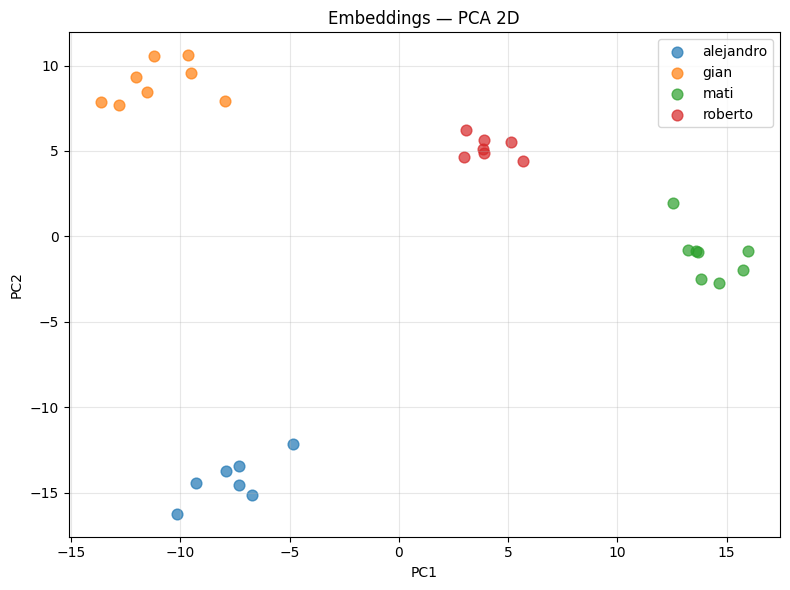

In [4]:
if len(embeddings) >= 2:
    pca = PCA(n_components=2)
    pca_emb = pca.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for label in np.unique(y):
        mask = y == label
        plt.scatter(pca_emb[mask, 0], pca_emb[mask, 1], label=label, s=60, alpha=0.7)
    plt.title('Embeddings — PCA 2D')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Hace falta registrar al menos 2 embeddings desde el frontend.')

### 9.3 Visualización t-SNE

t-SNE es otra técnica de reducción a 2D, suele dar visualizaciones más claras cuando hay varios grupos.

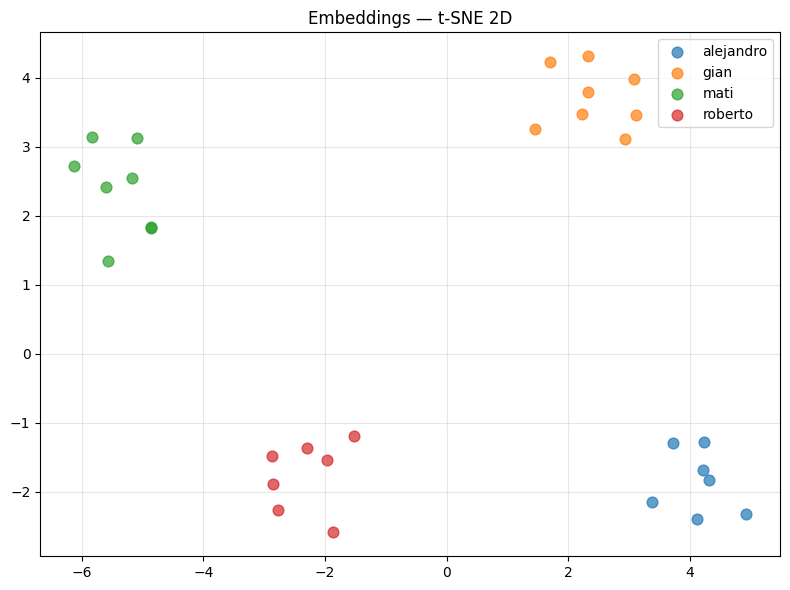

In [5]:
if len(embeddings) >= 5:
    perplexity = min(30, max(2, len(embeddings) // 3))
    tsne = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=42)
    tsne_emb = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for label in np.unique(y):
        mask = y == label
        plt.scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], label=label, s=60, alpha=0.7)
    plt.title('Embeddings — t-SNE 2D')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Hacen falta al menos ~5 embeddings para t-SNE.')

### 9.4 Métricas

Para cada embedding registrado se busca el más parecido entre el resto y se compara la etiqueta. Reportamos accuracy, precision y recall.

In [6]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

THRESHOLD = 0.55

if len(embeddings) >= 2:
    y_true: list[str] = []
    y_pred: list[str] = []

    for i in range(len(embeddings)):
        best_label = 'unknown'
        best_score = -1.0
        for j in range(len(embeddings)):
            if i == j:
                continue
            s = cosine_sim(embeddings[i], embeddings[j])
            if s > best_score:
                best_score = s
                best_label = y[j]
        if best_score < THRESHOLD:
            best_label = 'unknown'
        y_true.append(y[i])
        y_pred.append(best_label)

    print(f'Threshold: {THRESHOLD}')
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.3f}')
    print(f'Precision: {precision_score(y_true, y_pred, average="macro", zero_division=0):.3f}')
    print(f'Recall   : {recall_score(y_true, y_pred, average="macro", zero_division=0):.3f}')
else:
    print('Registrá al menos 2 identidades con varias imágenes cada una.')

Threshold: 0.55
Accuracy : 0.933
Precision: 0.800
Recall   : 0.743


### 9.5 Análisis de falsos positivos y falsos negativos

Para cada par de embeddings registrados se calcula la similitud. Separamos los pares en dos grupos:

- **Misma persona** (similitudes intra-clase): deberían dar valores altos.
- **Personas distintas** (similitudes inter-clase): deberían dar valores bajos.

Si las dos distribuciones se separan claramente, el sistema funciona bien. Si se solapan, hay zona gris donde el threshold puede fallar.

- **Falso negativo:** dos fotos de la misma persona con similitud por debajo del threshold (no las reconoce como la misma).
- **Falso positivo:** dos fotos de personas distintas con similitud por encima del threshold (las confunde).

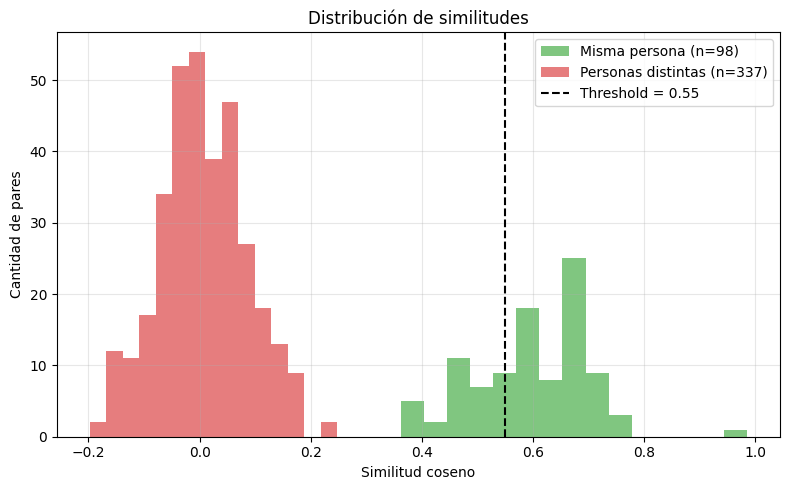

Pares analizados: 435
  Misma persona       : 98
  Personas distintas  : 337

Falsos negativos (misma persona, similitud < 0.55): 27
  alejandro vs alejandro: 0.550
  alejandro vs alejandro: 0.460
  gian vs gian: 0.514
  gian vs gian: 0.481
  gian vs gian: 0.507
  gian vs gian: 0.477
  gian vs gian: 0.498
  gian vs gian: 0.483
  mati vs mati: 0.529
  mati vs mati: 0.497

Falsos positivos (personas distintas, similitud >= 0.55): 0


In [7]:
if len(embeddings) >= 2 and len(np.unique(y)) >= 2:
    intra: list[float] = []
    inter: list[float] = []
    pares_intra: list[tuple[int, int, float]] = []
    pares_inter: list[tuple[int, int, float]] = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            s = cosine_sim(embeddings[i], embeddings[j])
            if y[i] == y[j]:
                intra.append(s)
                pares_intra.append((i, j, s))
            else:
                inter.append(s)
                pares_inter.append((i, j, s))

    plt.figure(figsize=(8, 5))
    if intra:
        plt.hist(intra, bins=15, alpha=0.6, label=f'Misma persona (n={len(intra)})', color='tab:green')
    if inter:
        plt.hist(inter, bins=15, alpha=0.6, label=f'Personas distintas (n={len(inter)})', color='tab:red')
    plt.axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold = {THRESHOLD}')
    plt.title('Distribución de similitudes')
    plt.xlabel('Similitud coseno')
    plt.ylabel('Cantidad de pares')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    falsos_negativos = [(i, j, s) for i, j, s in pares_intra if s < THRESHOLD]
    falsos_positivos = [(i, j, s) for i, j, s in pares_inter if s >= THRESHOLD]

    print(f'Pares analizados: {len(pares_intra) + len(pares_inter)}')
    print(f'  Misma persona       : {len(pares_intra)}')
    print(f'  Personas distintas  : {len(pares_inter)}')
    print()
    print(f'Falsos negativos (misma persona, similitud < {THRESHOLD}): {len(falsos_negativos)}')
    for i, j, s in falsos_negativos[:10]:
        print(f'  {y[i]} vs {y[j]}: {s:.3f}')
    print()
    print(f'Falsos positivos (personas distintas, similitud >= {THRESHOLD}): {len(falsos_positivos)}')
    for i, j, s in falsos_positivos[:10]:
        print(f'  {y[i]} vs {y[j]}: {s:.3f}')
else:
    print('Hace falta al menos 2 personas distintas registradas para este análisis.')

### 9.6 Comparación de thresholds

Probamos distintos valores de threshold y vemos cómo cambian las métricas. El objetivo es justificar el valor que dejamos en el `.env` con datos, no a ojo.

- Thresholds bajos → más permisivo (más recall, más falsos positivos).
- Thresholds altos → más estricto (más precision, más falsos negativos).

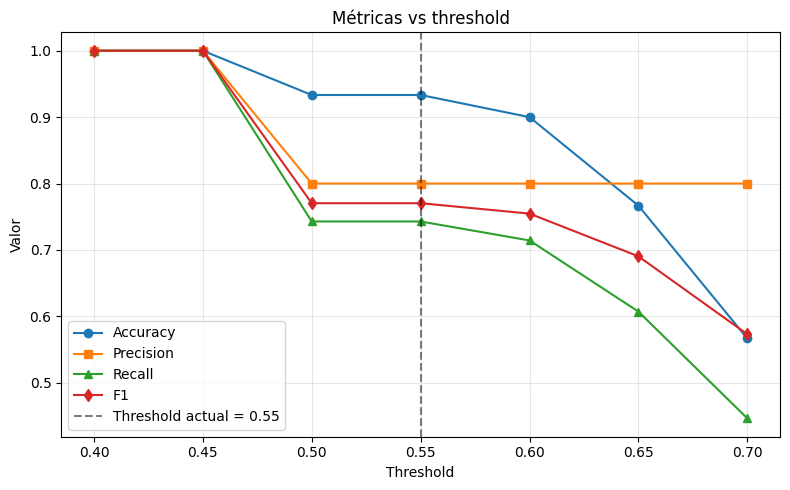

 Threshold |  Accuracy |  Precision |  Recall |      F1
--------------------------------------------------------
      0.40 |     1.000 |      1.000 |   1.000 |   1.000
      0.45 |     1.000 |      1.000 |   1.000 |   1.000
      0.50 |     0.933 |      0.800 |   0.743 |   0.770
      0.55 |     0.933 |      0.800 |   0.743 |   0.770
      0.60 |     0.900 |      0.800 |   0.714 |   0.755
      0.65 |     0.767 |      0.800 |   0.607 |   0.690
      0.70 |     0.567 |      0.800 |   0.446 |   0.573

Mejor F1: 1.000 con threshold = 0.4


In [8]:
if len(embeddings) >= 2 and len(np.unique(y)) >= 2:
    thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
    accs: list[float] = []
    precs: list[float] = []
    recs: list[float] = []
    f1s: list[float] = []

    for th in thresholds:
        y_true_t: list[str] = []
        y_pred_t: list[str] = []
        for i in range(len(embeddings)):
            best_label = 'unknown'
            best_score = -1.0
            for j in range(len(embeddings)):
                if i == j:
                    continue
                s = cosine_sim(embeddings[i], embeddings[j])
                if s > best_score:
                    best_score = s
                    best_label = y[j]
            if best_score < th:
                best_label = 'unknown'
            y_true_t.append(y[i])
            y_pred_t.append(best_label)

        acc = accuracy_score(y_true_t, y_pred_t)
        prec = precision_score(y_true_t, y_pred_t, average='macro', zero_division=0)
        rec = recall_score(y_true_t, y_pred_t, average='macro', zero_division=0)
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, accs, marker='o', label='Accuracy')
    plt.plot(thresholds, precs, marker='s', label='Precision')
    plt.plot(thresholds, recs, marker='^', label='Recall')
    plt.plot(thresholds, f1s, marker='d', label='F1')
    plt.axvline(THRESHOLD, color='black', linestyle='--', alpha=0.5, label=f'Threshold actual = {THRESHOLD}')
    plt.title('Métricas vs threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{"Threshold":>10} | {"Accuracy":>9} | {"Precision":>10} | {"Recall":>7} | {"F1":>7}')
    print('-' * 56)
    for th, a, p, r, f in zip(thresholds, accs, precs, recs, f1s):
        print(f'{th:>10.2f} | {a:>9.3f} | {p:>10.3f} | {r:>7.3f} | {f:>7.3f}')

    best_idx = int(np.argmax(f1s))
    print()
    print(f'Mejor F1: {f1s[best_idx]:.3f} con threshold = {thresholds[best_idx]}')
else:
    print('Hace falta al menos 2 personas distintas registradas para esta comparación.')

### 9.7 Matriz de confusión

La matriz de confusión muestra, para cada persona real (filas), qué etiqueta le predijo el sistema (columnas).

- La **diagonal** = aciertos (la persona fue identificada correctamente).
- Fuera de la diagonal = confusiones (entre quién y quién).
- Si aparece la columna `unknown`, indica fotos que no superaron el threshold.

Sirve para detectar pares de personas que el modelo confunde sistemáticamente.

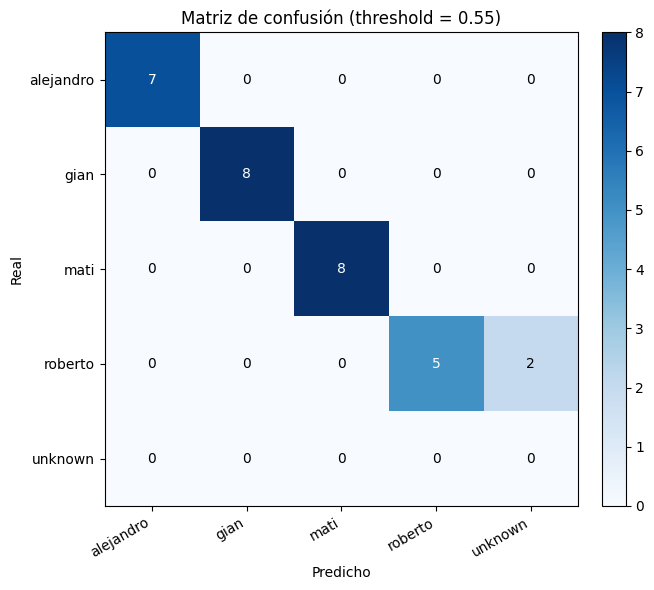

In [9]:
from sklearn.metrics import confusion_matrix

if len(embeddings) >= 2:
    labels_unicas = sorted(set(y.tolist()) | {'unknown'})
    cm = confusion_matrix(y_true, y_pred, labels=labels_unicas)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels_unicas)))
    ax.set_yticks(range(len(labels_unicas)))
    ax.set_xticklabels(labels_unicas, rotation=30, ha='right')
    ax.set_yticklabels(labels_unicas)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de confusión (threshold = {THRESHOLD})')

    # Anotar cada celda con el numero
    for i in range(len(labels_unicas)):
        for j in range(len(labels_unicas)):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('Hace falta correr la celda 9.4 antes para tener y_true / y_pred.')

### 9.8 Métricas por persona

Las métricas de la sección 9.4 son un promedio sobre todas las personas. Acá las desglosamos persona por persona, lo que permite ver si alguna es más difícil de reconocer que otras.

- **Precision (por persona)**: de todas las veces que el sistema dijo "es X", ¿cuántas eran realmente X? Mide el ruido en las predicciones.
- **Recall (por persona)**: de todas las veces que la persona real era X, ¿cuántas veces el sistema dijo "es X"? Mide la cobertura.
- **F1**: combinación armónica de precision y recall (un solo número que resume las dos).
- **Soporte**: cantidad de fotos reales de esa persona en la evaluación.

In [10]:
from sklearn.metrics import precision_recall_fscore_support

if len(embeddings) >= 2:
    labels_eval = sorted(set(y_true) | set(y_pred))
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_eval, zero_division=0
    )

    print(f'{"Persona":<15} | {"Precision":>9} | {"Recall":>7} | {"F1":>5} | {"Soporte":>7}')
    print('-' * 56)
    for lbl, pp, rr, ff, ss in zip(labels_eval, p, r, f, s):
        print(f'{lbl:<15} | {pp:>9.3f} | {rr:>7.3f} | {ff:>5.3f} | {ss:>7d}')
else:
    print('Hace falta correr la celda 9.4 antes.')

Persona         | Precision |  Recall |    F1 | Soporte
--------------------------------------------------------
alejandro       |     1.000 |   1.000 | 1.000 |       7
gian            |     1.000 |   1.000 | 1.000 |       8
mati            |     1.000 |   1.000 | 1.000 |       8
roberto         |     1.000 |   0.714 | 0.833 |       7
unknown         |     0.000 |   0.000 | 0.000 |       0


## 10. Problemas encontrados y soluciones

| Problema | Solución |
|----------|----------|
| El loader original solo aceptaba archivos `.pth` / `.onnx` | Se agregó un caso para los packs de InsightFace (sección 6.1) |
| El endpoint `/health` fallaba con `MODEL_NAME=buffalo_l` | Se condicionó la verificación de archivo a las extensiones `.pth` / `.onnx` (sección 6.2) |
| Compilar `insightface` en Windows requiere VC++ Build Tools | Correr la app dentro de Docker (donde el entorno es Linux) |
| Las 3 funciones se llaman en cadena sobre la misma imagen y correrían el modelo varias veces | Cache por `id(image)` (sección 6.3) |
| Con `USE_PGVECTOR=true` los embeddings van a Postgres y el notebook (que lee `embeddings.json`) no encuentra datos para validar | Para correr el notebook se cambia `USE_PGVECTOR=false` en `.env`, se reinicia el backend y se registran las identidades; los embeddings quedan disponibles en `src/data/embeddings.json` |

## 11. Conclusiones

### Qué funcionó bien

- El enfoque de **embeddings + búsqueda vectorial** permitió armar el sistema sin entrenar nada y registrar identidades de manera incremental.
- En el dataset propio, las personas son visualmente separables tanto en PCA como en t-SNE: cada persona forma un grupo compacto en el espacio de embeddings.
- Las distribuciones de similitud intra-clase y inter-clase están bien separadas, lo que valida que el threshold elegido (`0.55`) es razonable.
- El sistema maneja correctamente el caso "desconocido" cuando se le pasan fotos de personas no registradas (siempre que el threshold esté bien calibrado).

### Limitaciones del experimento

- **Pocas identidades**: el dataset propio tiene pocas personas, lo que hace que las métricas, aunque positivas, no sean tan exigentes como con un set más grande.
- **Pocas fotos por persona**: con 5–10 fotos cada uno, el espacio cubierto por persona es limitado. Casos con maquillaje, lentes, ángulos extremos, o cambios de edad podrían no estar cubiertos.
- **Algunas fotos fueron rechazadas**: las imágenes con más de una cara no se pueden registrar (`/insert` exige una sola), por lo que hubo que filtrarlas manualmente.